In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.sparse import diags

In [2]:
# def montaMatriz(theta, n, h):
#     M = np.zeros((n-2, n-2))
#     for i in range(n-2):
#         for j in range(n-2):
#             if i == j:
#                 M[i][j] = -2.0 +h**2 * np.cos(theta[i+1])
#             elif (j == i+1) or (j == i-1): 
#                 M[i][j] = 1.0
#     return (1/h**2)*M






 



#matriz esparça , numpy ou array
#algoritmo de thomas para a solução do sistema


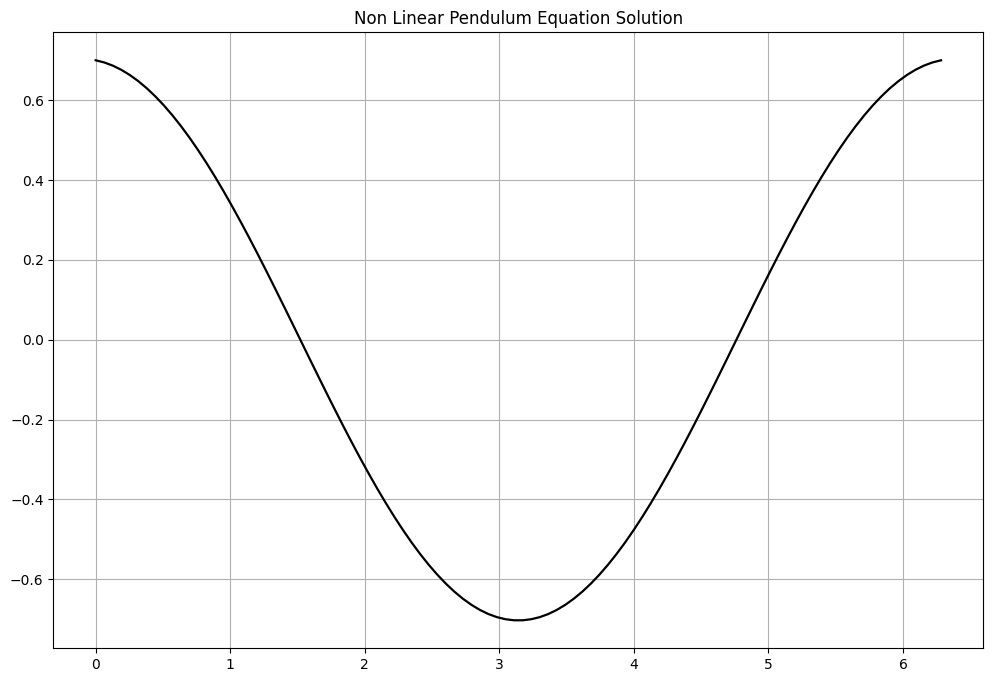

In [3]:
def montaMatrizEsparsa(theta, n, h):
    principal = np.zeros(n-2)
    principal[:] = (-2.0 +h**2 * np.cos(theta[1:-1]))
    adjacente = np.ones(n-3)
    M_esparsa = diags([adjacente, principal, adjacente], [-1, 0, 1]).toarray()
    
    return (1/h**2) * M_esparsa




def thomasTridiagonalSolver(a,b,c,d):
    n = len(d)
    w= np.zeros(n-1,float)
    g= np.zeros(n, float)
    p = np.zeros(n,float)
    
    w[0] = c[0]/b[0]
    g[0] = d[0]/b[0]

    for i in range(1,n-1):
        w[i] = c[i]/(b[i] - a[i-1]*w[i-1])
    for i in range(1,n):
        g[i] = (d[i] - a[i-1]*g[i-1])/(b[i] - a[i-1]*w[i-1])
    p[n-1] = g[n-1]
    for i in range(n-1,0,-1):
        p[i-1] = g[i-1] - w[i-1]*p[i]
    return p


n = 100 
# theta = np.linspace(0.7, 0.7, n)
theta = np.zeros(n)

#boundary conditions
theta[0] = 0.7
theta[-1] = 0.7

tf = 2.0 * np.pi 
h = tf / (n - 1)


maxit = 10





for k in range(maxit):
    
    G = np.zeros(n-2)
    for i in range(1, n-1):
        G[i-1] = (theta[i-1] - 2*theta[i] + theta[i+1]) / h**2 + np.sin(theta[i])
    
    M = montaMatrizEsparsa(theta, n, h)
    # delta = np.linalg.solve(M, -G)
    delta = thomasTridiagonalSolver(M.diagonal(-1), M.diagonal(0), M.diagonal(1), -G)
    
    for i in range(n-2):
        theta[i+1] += delta[i]
    

xplot = np.linspace(0, tf, n)
plt.figure(figsize=(12,8))
plt.plot(xplot, theta,color = 'black' , linewidth=1.6)
plt.title('Non Linear Pendulum Equation Solution')
plt.grid(True)
plt.show()


In [4]:
a = np.linspace(1000,10000,20)
print(len(a))
print(a)


20
[ 1000.          1473.68421053  1947.36842105  2421.05263158
  2894.73684211  3368.42105263  3842.10526316  4315.78947368
  4789.47368421  5263.15789474  5736.84210526  6210.52631579
  6684.21052632  7157.89473684  7631.57894737  8105.26315789
  8578.94736842  9052.63157895  9526.31578947 10000.        ]
